<a href="https://colab.research.google.com/github/indujagannathan/Internship-/blob/main/INDUJAGAN2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd

In [4]:
df= pd.read_csv('/content/drive/MyDrive/Car_sales.csv')

In [5]:
df.head()

,Manufacturer,Model,Sales_in_thousands,__year_resale_value,Vehicle_type,Price_in_thousands,Engine_size,Horsepower,Wheelbase,Width,Length,Curb_weight,Fuel_capacity,Fuel_efficiency,Latest_Launch,Power_perf_factor
0,Acura,Integra,16.919,16.360,Passenger,21.50,1.8,140.0,101.2,67.3,172.4,2.639,13.2,28.0,2/2/2012,58.280150
1,Acura,TL,39.384,19.875,Passenger,28.40,3.2,225.0,108.1,70.3,192.9,3.517,17.2,25.0,6/3/2011,91.370778
2,Acura,CL,14.114,18.225,Passenger,NaN,3.2,225.0,106.9,70.6,192.0,3.470,17.2,26.0,1/4/2012,NaN
3,Acura,RL,8.588,29.725,Passenger,42.00,3.5,210.0,114.6,71.4,196.6,3.850,18.0,22.0,3/10/2011,91.389779
4,Audi,A4,20.397,22.255,Passenger,23.99,1.8,150.0,102.6,68.2,178.0,2.998,16.4,27.0,10/8/2011,62.777639


Linear Regression Performance:
Mean Absolute Error: 14.556221966752098
Mean Squared Error: 211.8835979453563

Random Forest Performance:
Mean Absolute Error: 49.817399999999985
Mean Squared Error: 2481.7733427599983


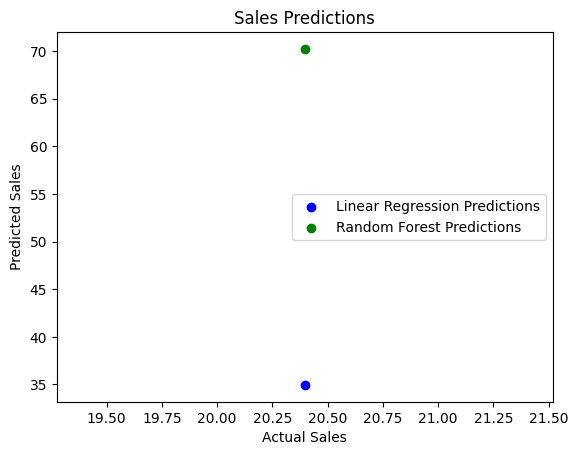

In [6]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt


data = {
    "Manufacturer": ["Acura", "Audi", "BMW", "Buick", "Chevrolet"],
    "Model": ["Integra", "A4", "323i", "Century", "Cavalier"],
    "Sales_in_thousands": [16.919, 20.397, 19.747, 91.561, 145.519],
    "Price_in_thousands": [21.5, 23.99, 26.99, 21.975, 13.26],
}

df = pd.DataFrame(data)

df = df.dropna()
df = pd.get_dummies(df, columns=['Manufacturer', 'Model'], drop_first=True)  # One-hot encode categorical variables


X = df.drop('Sales_in_thousands', axis=1)
y = df['Sales_in_thousands']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
y_pred_linear = linear_model.predict(X_test)


rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)


def evaluate_model(y_test, y_pred):
    print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred))
    print("Mean Squared Error:", mean_squared_error(y_test, y_pred))

print("Linear Regression Performance:")
evaluate_model(y_test, y_pred_linear)

print("\nRandom Forest Performance:")
evaluate_model(y_test, y_pred_rf)


plt.scatter(y_test, y_pred_linear, color='blue', label='Linear Regression Predictions')
plt.scatter(y_test, y_pred_rf, color='green', label='Random Forest Predictions')
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.title('Sales Predictions')
plt.legend()
plt.show()
